# Exoplanet Classification with SVM and Decision Trees

This notebook explores a coursework exoplanet dataset and builds interpretable classical machine-learning models.

**Main goals**
- understand class balance and discovery patterns;
- compare linear SVMs with and without scaling;
- tune an RBF SVM using validation data only;
- study decision-tree complexity and pruning without using the test set for model selection;
- identify extreme observations and test whether removing training-set outliers improves generalization.

The final test set is kept untouched until the selected models are evaluated.

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_PATH = Path('../data/exoplanet.csv')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Expected ../data/exoplanet.csv. See data/README.md for setup instructions.'
    )

df = pd.read_csv(DATA_PATH)
features = ['pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'st_teff', 'st_rad', 'st_mass']
df_clean = df.dropna(subset=features + ['planet_class']).copy()

print(f'Rows used: {len(df_clean):,}')
print(f'Features: {len(features)}')
print(df_clean['planet_class'].value_counts())

Rows used: 6,004
Features: 7
planet_class
Super-Earth     2195
Gas Giant       1734
Neptune-like    1079
Terrestrial      996
Name: count, dtype: int64


## 1. Class distribution and feature overview

The target is somewhat imbalanced, so accuracy alone can hide poor performance on the smaller classes. Macro-F1 is therefore reported alongside accuracy later in the notebook.

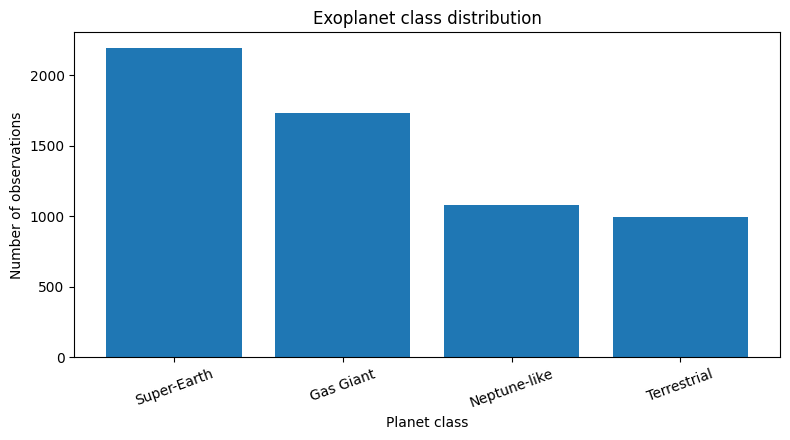

,pl_bmasse,pl_orbsmax,st_teff
planet_class,,,
Gas Giant,514.09,0.59,5587.0
Neptune-like,16.00,0.14,5597.0
Super-Earth,5.82,0.09,5499.0
Terrestrial,2.02,0.05,5282.0


In [2]:
class_counts = df_clean['planet_class'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(class_counts.index, class_counts.values)
ax.set_title('Exoplanet class distribution')
ax.set_xlabel('Planet class')
ax.set_ylabel('Number of observations')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / 'class_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

summary = df_clean.groupby('planet_class')[['pl_bmasse', 'pl_orbsmax', 'st_teff']].median().round(2)
display(summary)

## 2. Discovery patterns over time

Discovery counts are summarized by year and by five-year period. These plots are descriptive only; discovery year is not used as a classification feature.

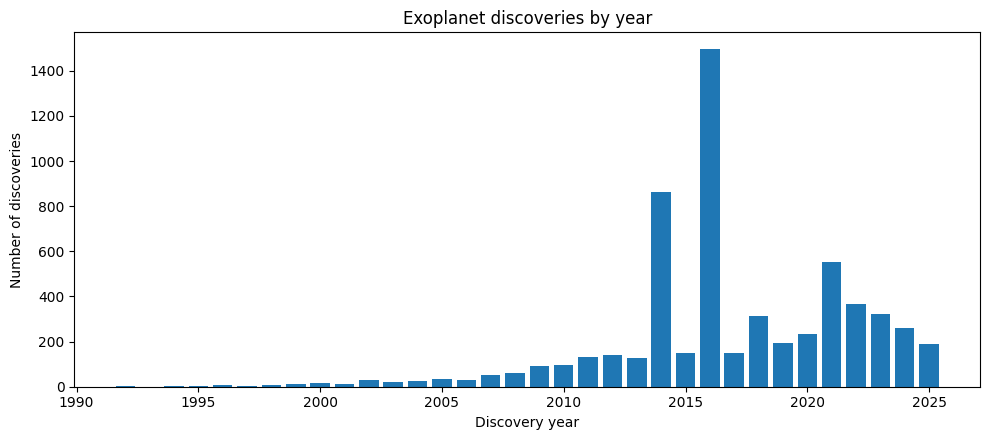

planet_class,Gas Giant,Neptune-like,Super-Earth,Terrestrial
year_period,,,,
1990-1994,0,0,2,1
1995-1999,27,0,0,0
2000-2004,95,8,1,0
2005-2009,227,33,15,1
2010-2014,351,222,545,243
2015-2019,431,395,988,492
2020-2024,512,378,609,238
2025-2029,91,43,35,21


In [3]:
yearly = df_clean.groupby('disc_year').size()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(yearly.index.astype(int), yearly.values)
ax.set_title('Exoplanet discoveries by year')
ax.set_xlabel('Discovery year')
ax.set_ylabel('Number of discoveries')
fig.tight_layout()
fig.savefig(FIG_DIR / 'discoveries_over_time.png', dpi=160, bbox_inches='tight')
plt.show()

start = int(df_clean['disc_year'].min() // 5 * 5)
end = int(np.ceil(df_clean['disc_year'].max() / 5) * 5 + 5)
bins = list(range(start, end + 1, 5))
labels = [f'{b}-{b+4}' for b in bins[:-1]]
df_clean['year_period'] = pd.cut(df_clean['disc_year'], bins=bins, labels=labels, right=False)
period_class = pd.crosstab(df_clean['year_period'], df_clean['planet_class'])
display(period_class)

## 3. Train / validation / test split

A separate validation set is used for hyperparameter selection. The test set is reserved for the final unbiased evaluation.

In [4]:
X = df_clean[features]
y = df_clean['planet_class']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: (3842, 7) Validation: (961, 7) Test: (1201, 7)


## 4. Linear SVM: effect of scaling

Linear SVMs are sensitive to feature scale because the input variables have very different physical units.

In [5]:
linear_no_scale = LinearSVC(class_weight='balanced', max_iter=10000, random_state=SEED, dual='auto')
linear_no_scale.fit(X_train, y_train)

linear_scaled = LinearSVC(class_weight='balanced', max_iter=10000, random_state=SEED, dual='auto')
linear_scaled.fit(X_train_scaled, y_train)

rows = []
for name, model, Xv in [
    ('LinearSVC - no scaling', linear_no_scale, X_val),
    ('LinearSVC - standardized', linear_scaled, X_val_scaled),
]:
    pred = model.predict(Xv)
    rows.append({
        'model': name,
        'validation_accuracy': accuracy_score(y_val, pred),
        'validation_macro_f1': f1_score(y_val, pred, average='macro')
    })

display(pd.DataFrame(rows).set_index('model').round(3))

coef = np.abs(linear_scaled.coef_).sum(axis=0)
importance = pd.Series(coef, index=features).sort_values(ascending=False)
print('Linear SVM coefficient importance (absolute sum across classes):')
display(importance.to_frame('importance').round(3))

,validation_accuracy,validation_macro_f1
model,,
LinearSVC - no scaling,0.589,0.380
LinearSVC - standardized,0.605,0.503


Linear SVM coefficient importance (absolute sum across classes):


,importance
pl_orbsmax,6.954
pl_bmasse,3.145
st_rad,1.513
st_mass,0.666
pl_orbeccen,0.606
st_teff,0.340
pl_orbper,0.224


## 5. RBF SVM: tune on validation, evaluate once on test

`C` and `gamma` are chosen using the validation set. The test set is not used to select hyperparameters.

,C,gamma,train_accuracy,validation_accuracy,validation_macro_f1,support_vectors
8,10.0,1.00,0.636,0.585,0.569,3023
7,10.0,0.10,0.611,0.593,0.561,2980
4,1.0,0.10,0.585,0.583,0.550,3176
6,10.0,0.01,0.591,0.585,0.543,3120
5,1.0,1.00,0.586,0.544,0.525,3185
2,0.1,1.00,0.553,0.538,0.504,3429
1,0.1,0.10,0.532,0.546,0.502,3406
3,1.0,0.01,0.543,0.547,0.497,3352
0,0.1,0.01,0.475,0.489,0.394,3605


Selected on validation: C=10, gamma=1


Final RBF SVM test accuracy: 0.584
Final RBF SVM test macro-F1: 0.564
              precision    recall  f1-score   support

   Gas Giant       0.94      0.88      0.91       347
Neptune-like       0.47      0.48      0.48       216
 Super-Earth       0.54      0.46      0.49       439
 Terrestrial       0.32      0.45      0.37       199

    accuracy                           0.58      1201
   macro avg       0.57      0.57      0.56      1201
weighted avg       0.61      0.58      0.59      1201



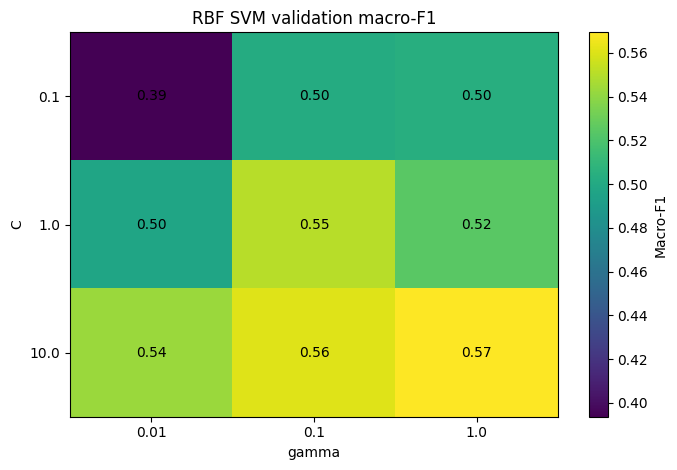

In [6]:
C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]
results = []
models = {}

for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced')
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
        results.append({
            'C': C,
            'gamma': gamma,
            'train_accuracy': accuracy_score(y_train, train_pred),
            'validation_accuracy': accuracy_score(y_val, val_pred),
            'validation_macro_f1': f1_score(y_val, val_pred, average='macro'),
            'support_vectors': len(model.support_)
        })
        models[(C, gamma)] = model

svm_results = pd.DataFrame(results).sort_values(
    ['validation_macro_f1', 'validation_accuracy'], ascending=False
)
display(svm_results.round(3))

best_row = svm_results.iloc[0]
best_C = float(best_row['C'])
best_gamma = float(best_row['gamma'])
print(f'Selected on validation: C={best_C:g}, gamma={best_gamma:g}')

# Refit the selected configuration on train + validation, then evaluate once on test.
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(X_trainval)
X_test_final_scaled = final_scaler.transform(X_test)

rbf_final = SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced')
rbf_final.fit(X_trainval_scaled, y_trainval)
rbf_test_pred = rbf_final.predict(X_test_final_scaled)

print('Final RBF SVM test accuracy:', round(accuracy_score(y_test, rbf_test_pred), 3))
print('Final RBF SVM test macro-F1:', round(f1_score(y_test, rbf_test_pred, average='macro'), 3))
print(classification_report(y_test, rbf_test_pred, zero_division=0))

pivot = svm_results.pivot(index='C', columns='gamma', values='validation_macro_f1').sort_index()
fig, ax = plt.subplots(figsize=(7, 4.8))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)), labels=[str(v) for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)), labels=[str(v) for v in pivot.index])
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('RBF SVM validation macro-F1')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='Macro-F1')
fig.tight_layout()
fig.savefig(FIG_DIR / 'svm_validation_grid.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Decision Tree pruning without test-set leakage

The original unpruned tree is useful for demonstrating overfitting. `ccp_alpha` is selected on the validation set, then the chosen tree is refit on train + validation and evaluated on the untouched test set.

Selected ccp_alpha: 0.000716193
Final Decision Tree test accuracy: 0.923
Final Decision Tree test macro-F1: 0.916


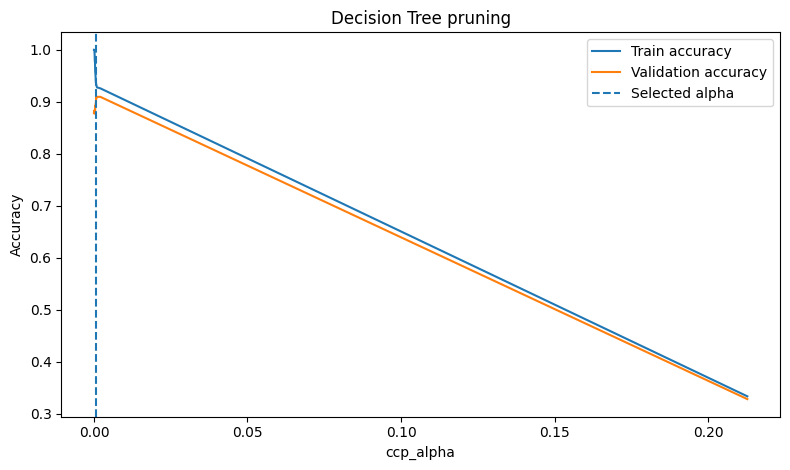

,importance
pl_bmasse,0.970
pl_orbsmax,0.011
pl_orbeccen,0.009
st_rad,0.004
pl_orbper,0.003
st_mass,0.002
st_teff,0.001


|--- pl_bmasse <= 2.87
|   |--- pl_bmasse <= 0.01
|   |   |--- class: Gas Giant
|   |--- pl_bmasse >  0.01
|   |   |--- class: Terrestrial
|--- pl_bmasse >  2.87
|   |--- pl_bmasse <= 72.13
|   |   |--- pl_bmasse <= 9.28
|   |   |   |--- pl_orbper <= 1.72
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- pl_orbper >  1.72
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- pl_bmasse >  9.28
|   |   |   |--- pl_orbsmax <= 0.29
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- pl_orbsmax >  0.29
|   |   |   |   |--- class: Neptune-like
|   |--- pl_bmasse >  72.13
|   |   |--- pl_bmasse <= 129.50
|   |   |   |--- pl_orbsmax <= 0.72
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- pl_orbsmax >  0.72
|   |   |   |   |--- class: Gas Giant
|   |   |--- pl_bmasse >  129.50
|   |   |   |--- pl_orbsmax <= 0.65
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- pl_orbsmax >  0.65
|   |   |   |   |--- class: Gas Giant



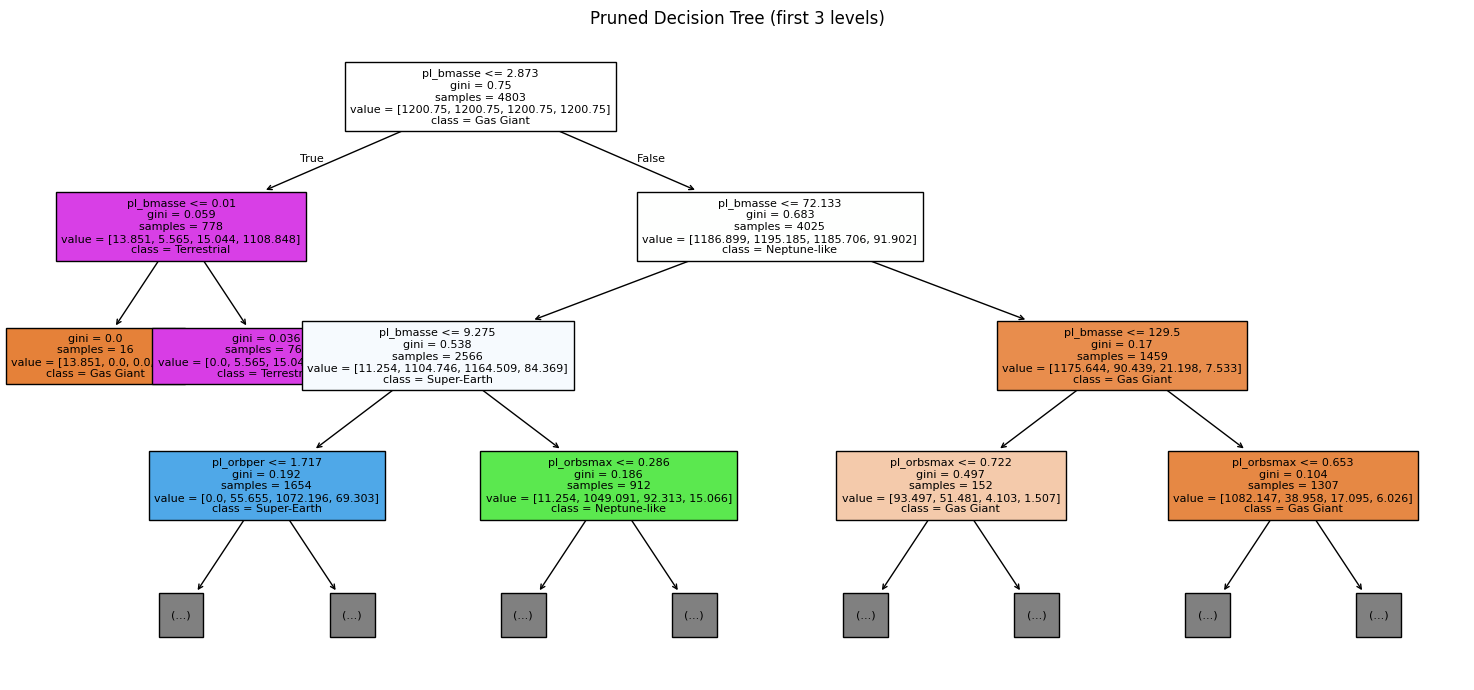

In [7]:
base_tree = DecisionTreeClassifier(random_state=SEED, class_weight='balanced')
base_tree.fit(X_train, y_train)

path = base_tree.cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(path.ccp_alphas)
if len(alphas) > 45:
    idx = np.linspace(0, len(alphas) - 2, 45, dtype=int)
    alphas = alphas[idx]

pruning_rows = []
for alpha in alphas:
    tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=float(alpha), class_weight='balanced')
    tree.fit(X_train, y_train)
    pruning_rows.append({
        'ccp_alpha': float(alpha),
        'train_accuracy': accuracy_score(y_train, tree.predict(X_train)),
        'validation_accuracy': accuracy_score(y_val, tree.predict(X_val)),
        'validation_macro_f1': f1_score(y_val, tree.predict(X_val), average='macro')
    })

pruning_df = pd.DataFrame(pruning_rows)
best_tree_row = pruning_df.sort_values(
    ['validation_macro_f1', 'validation_accuracy'], ascending=False
).iloc[0]
best_alpha = float(best_tree_row['ccp_alpha'])
print(f'Selected ccp_alpha: {best_alpha:.6g}')

final_tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=best_alpha, class_weight='balanced')
final_tree.fit(X_trainval, y_trainval)
tree_test_pred = final_tree.predict(X_test)
print('Final Decision Tree test accuracy:', round(accuracy_score(y_test, tree_test_pred), 3))
print('Final Decision Tree test macro-F1:', round(f1_score(y_test, tree_test_pred, average='macro'), 3))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(pruning_df['ccp_alpha'], pruning_df['train_accuracy'], label='Train accuracy')
ax.plot(pruning_df['ccp_alpha'], pruning_df['validation_accuracy'], label='Validation accuracy')
ax.axvline(best_alpha, linestyle='--', label='Selected alpha')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree pruning')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'decision_tree_pruning.png', dpi=160, bbox_inches='tight')
plt.show()

feature_importance = pd.Series(final_tree.feature_importances_, index=features).sort_values(ascending=False)
display(feature_importance.to_frame('importance').round(3))
print(export_text(final_tree, feature_names=features, max_depth=3))

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(final_tree, feature_names=features, class_names=final_tree.classes_, filled=True, max_depth=3, fontsize=8, ax=ax)
ax.set_title('Pruned Decision Tree (first 3 levels)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'decision_tree_preview.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Outlier analysis with a fair comparison

IQR thresholds are learned from the training data only. For the performance comparison, outliers are removed **only from the training data** and both versions are evaluated on the same untouched test set. This avoids making the test task artificially easier.

In [8]:
def learn_iqr_bounds(frame, columns, factor=1.5):
    bounds = {}
    for col in columns:
        q1 = frame[col].quantile(0.25)
        q3 = frame[col].quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (q1 - factor * iqr, q3 + factor * iqr)
    return bounds

def outlier_mask(frame, bounds):
    mask = pd.Series(False, index=frame.index)
    for col, (low, high) in bounds.items():
        mask |= (frame[col] < low) | (frame[col] > high)
    return mask

bounds = learn_iqr_bounds(X_trainval, features)
trainval_outlier_mask = outlier_mask(X_trainval, bounds)
test_outlier_mask = outlier_mask(X_test, bounds)

print(f'Train+validation outliers: {trainval_outlier_mask.sum():,} / {len(X_trainval):,}')
print(f'Test observations flagged as outliers: {test_outlier_mask.sum():,} / {len(X_test):,}')

# Inspect test-set outliers using the already-fitted final scaler/model.
X_test_outliers = X_test.loc[test_outlier_mask]
y_test_outliers = y_test.loc[test_outlier_mask]
if len(X_test_outliers):
    outlier_scaled = final_scaler.transform(X_test_outliers)
    outlier_svm_pred = rbf_final.predict(outlier_scaled)
    outlier_tree_pred = final_tree.predict(X_test_outliers)
    inspect = df_clean.loc[X_test_outliers.index, ['pl_name', 'planet_class'] + features].copy()
    inspect['RBF_SVM_prediction'] = outlier_svm_pred
    inspect['DecisionTree_prediction'] = outlier_tree_pred
    display(inspect.head(12))

# Retrain after removing only training-set outliers; test set stays exactly the same.
X_trainval_clean = X_trainval.loc[~trainval_outlier_mask]
y_trainval_clean = y_trainval.loc[~trainval_outlier_mask]

clean_scaler = StandardScaler()
X_trainval_clean_scaled = clean_scaler.fit_transform(X_trainval_clean)
X_test_clean_scaled = clean_scaler.transform(X_test)

rbf_clean = SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced')
rbf_clean.fit(X_trainval_clean_scaled, y_trainval_clean)
rbf_clean_pred = rbf_clean.predict(X_test_clean_scaled)

clean_tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=best_alpha, class_weight='balanced')
clean_tree.fit(X_trainval_clean, y_trainval_clean)
clean_tree_pred = clean_tree.predict(X_test)

comparison = pd.DataFrame([
    {'model': 'RBF SVM - all training data', 'test_accuracy': accuracy_score(y_test, rbf_test_pred), 'test_macro_f1': f1_score(y_test, rbf_test_pred, average='macro')},
    {'model': 'RBF SVM - training outliers removed', 'test_accuracy': accuracy_score(y_test, rbf_clean_pred), 'test_macro_f1': f1_score(y_test, rbf_clean_pred, average='macro')},
    {'model': 'Decision Tree - all training data', 'test_accuracy': accuracy_score(y_test, tree_test_pred), 'test_macro_f1': f1_score(y_test, tree_test_pred, average='macro')},
    {'model': 'Decision Tree - training outliers removed', 'test_accuracy': accuracy_score(y_test, clean_tree_pred), 'test_macro_f1': f1_score(y_test, clean_tree_pred, average='macro')},
]).set_index('model')
display(comparison.round(3))

Train+validation outliers: 1,734 / 4,803
Test observations flagged as outliers: 421 / 1,201


,pl_name,planet_class,pl_bmasse,pl_orbper,pl_orbsmax,pl_orbeccen,st_teff,st_rad,st_mass,RBF_SVM_prediction,DecisionTree_prediction
1229,HD 82943 c,Gas Giant,622.603000,220.078000,0.74345,0.3663,5935.0,1.18260,1.080,Gas Giant,Gas Giant
5714,TYC 3318-01333-1 b,Gas Giant,1086.978600,562.000000,1.41400,0.0980,4776.0,5.90000,1.190,Gas Giant,Gas Giant
3035,Kepler-1708 b,Neptune-like,1462.010672,737.113100,1.64000,0.4000,6157.0,1.11700,1.088,Gas Giant,Gas Giant
1964,KMT-2019-BLG-1715L b,Gas Giant,813.640722,0.000000,3.32000,0.0000,0.0,0.00000,0.610,Gas Giant,Gas Giant
5009,OGLE-2018-BLG-0962L b,Gas Giant,425.890065,0.000000,3.59000,0.0000,0.0,0.00000,0.540,Gas Giant,Gas Giant
292,GJ 649 b,Gas Giant,81.999729,600.100000,1.11200,0.0830,3734.0,0.50000,0.510,Neptune-like,Gas Giant
5710,TYC 0434-04538-1 b,Gas Giant,1938.763000,193.200000,0.66000,0.0800,4679.0,9.99000,1.040,Gas Giant,Gas Giant
20,2MASS J12073346-3932539 b,Gas Giant,1589.150000,0.000000,55.00000,0.0000,2825.0,0.21887,0.024,Gas Giant,Gas Giant
467,HATS-53 b,Gas Giant,189.108850,3.853777,0.04753,0.3300,5644.0,1.10100,0.964,Gas Giant,Gas Giant
737,HD 156411 b,Gas Giant,235.180000,842.200000,1.88000,0.2200,5900.0,2.16000,1.250,Gas Giant,Gas Giant


,test_accuracy,test_macro_f1
model,,
RBF SVM - all training data,0.584,0.564
RBF SVM - training outliers removed,0.512,0.505
Decision Tree - all training data,0.923,0.916
Decision Tree - training outliers removed,0.891,0.881


## Takeaways

- Scaling is important for SVMs because the physical features have very different numerical ranges.
- Hyperparameters are selected on validation data rather than the test set.
- Decision-tree pruning substantially reduces complexity while preserving strong predictive performance.
- Extreme observations should not automatically be removed: the fair comparison above measures whether removal actually improves generalization on the same test distribution.